In [17]:
# 1. Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)


In [18]:
# 2. Load the Dataset.
data = fetch_openml(
    name="diabetes",
    version=1,
    as_frame=True,
    parser="auto"
)

X = data.data

# 0 = No Diabetes, 1 = Diabetes
y = (data.target == "tested_positive").astype(int)
y = pd.Series(y.values, name="target")

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (768, 8)
Target shape: (768,)


In [19]:
# 3. Split the data into Training and Testing sets
# 80% to train, 20% held out to test -- no scaling needed, since neither a
# Decision Tree nor a Random Forest uses distance calculations.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)


Training features: (614, 8)
Testing features : (154, 8)


In [ ]:
# 4. Train a Single Decision Tree
# We leave max_depth unrestricted here on purpose -- exactly the "passionate
# expert who overthinks things" behavior described in class -- so we can see
# the overfitting problem that Random Forests are designed to fix.
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

tree_train_predictions = tree_model.predict(X_train)
tree_test_predictions = tree_model.predict(X_test)

print("DECISION TREE")
print("Tree depth :", tree_model.get_depth())
print("Tree leaves:", tree_model.get_n_leaves())
print(f"Training Accuracy: {accuracy_score(y_train, tree_train_predictions):.4f}")
print(f"Testing Accuracy : {accuracy_score(y_test, tree_test_predictions):.4f}")


DECISION TREE
Tree depth : 16
Tree leaves: 115
Training Accuracy: 1.0000
Testing Accuracy : 0.7273


In [ ]:
# 5. Train a Random Forest

forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    oob_score=True
)
forest_model.fit(X_train, y_train)

forest_train_predictions = forest_model.predict(X_train)
forest_test_predictions = forest_model.predict(X_test)

print("RANDOM FOREST")
print(f"Training Accuracy: {accuracy_score(y_train, forest_train_predictions):.4f}")
print(f"Testing Accuracy : {accuracy_score(y_test, forest_test_predictions):.4f}")
print(f"Out-of-Bag (OOB) Score: {forest_model.oob_score_:.4f}")


RANDOM FOREST
Training Accuracy: 1.0000
Testing Accuracy : 0.7727
Out-of-Bag (OOB) Score: 0.7524


In [ ]:
# 6. Compare Performance -- Decision Tree vs Random Forest
models = {
    "Decision Tree": (tree_model, tree_test_predictions),
    "Random Forest": (forest_model, forest_test_predictions)
}

model_names = []
accuracy_list = []
precision_list = []
recall_list = []
f1_list = []

for name, (model, predictions) in models.items():
    print("=" * 60)
    print(f"MODEL: {name}")
    print("=" * 60)

    acc = accuracy_score(y_test, predictions)
    prec = precision_score(y_test, predictions, zero_division=0)
    rec = recall_score(y_test, predictions, zero_division=0)
    f1 = f1_score(y_test, predictions, zero_division=0)

    model_names.append(name)
    accuracy_list.append(acc)
    precision_list.append(prec)
    recall_list.append(rec)
    f1_list.append(f1)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print()

    print(classification_report(
        y_test,
        predictions,
        target_names=["No Diabetes", "Diabetes"],
        zero_division=0
    ))

comparison_table = pd.DataFrame({
    "Model": model_names,
    "Accuracy": accuracy_list,
    "Precision": precision_list,
    "Recall": recall_list,
    "F1-Score": f1_list
})

display(comparison_table)


MODEL: Decision Tree
Accuracy : 0.7273
Precision: 0.6429
Recall   : 0.5000
F1-Score : 0.5625

              precision    recall  f1-score   support

 No Diabetes       0.76      0.85      0.80       100
    Diabetes       0.64      0.50      0.56        54

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.68       154
weighted avg       0.72      0.73      0.72       154

MODEL: Random Forest
Accuracy : 0.7727
Precision: 0.7111
Recall   : 0.5926
F1-Score : 0.6465

              precision    recall  f1-score   support

 No Diabetes       0.80      0.87      0.83       100
    Diabetes       0.71      0.59      0.65        54

    accuracy                           0.77       154
   macro avg       0.75      0.73      0.74       154
weighted avg       0.77      0.77      0.77       154



,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.727273,0.642857,0.500000,0.562500
1,Random Forest,0.772727,0.711111,0.592593,0.646465


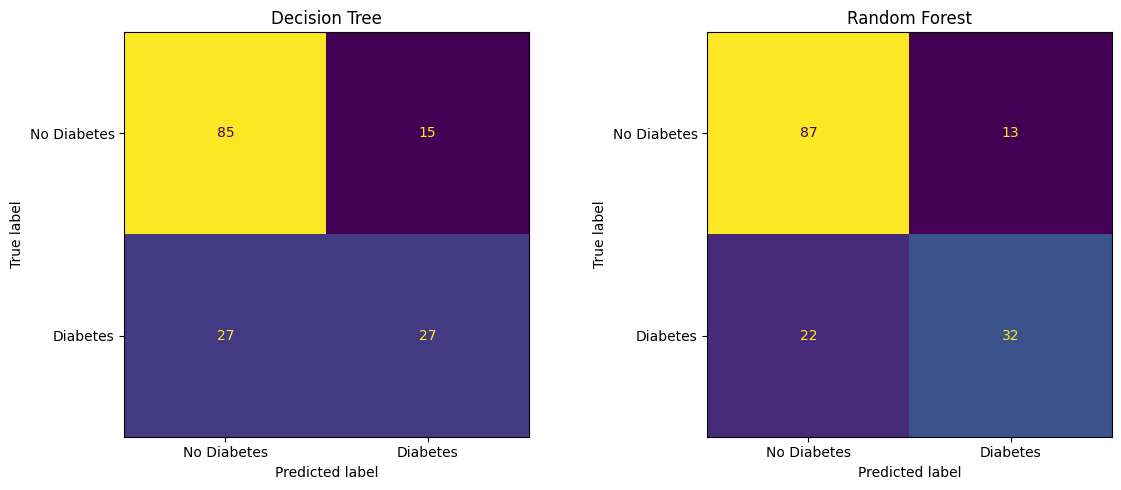

In [23]:
# 7. Compare Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, (model, predictions)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Diabetes", "Diabetes"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()


Random Forest Feature Importance:
plas    0.275636
mass    0.159477
age     0.127789
pedi    0.126668
pres    0.085612
preg    0.083875
insu    0.072788
skin    0.068156
dtype: float64


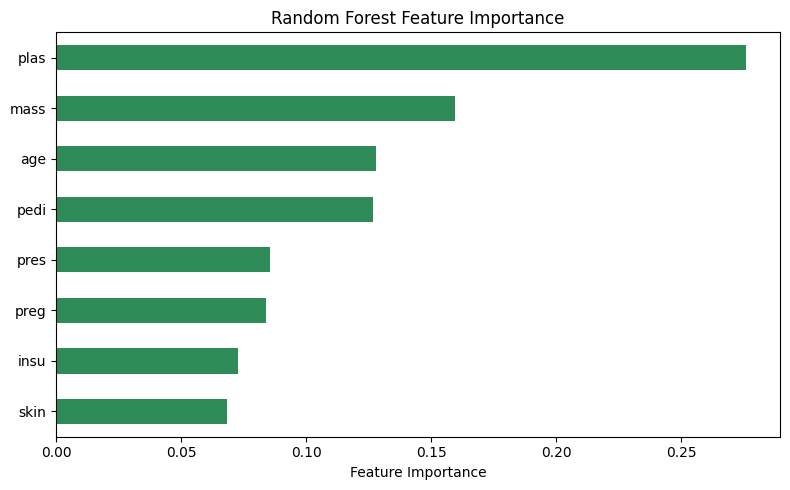

In [ ]:
# 8. Feature Importance -- Random Forest
# Just like a single tree, a Random Forest tracks how much each feature reduces
# impurity across ALL of its trees, giving a more stable importance ranking.
forest_importance = pd.Series(
    forest_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Random Forest Feature Importance:")
print(forest_importance)

plt.figure(figsize=(8, 5))
forest_importance.sort_values().plot(kind="barh", color="seagreen")
plt.title("Random Forest Feature Importance")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()


## Comparison and Interpretation

### Performance
The single, unrestricted Decision Tree reached **100% Training Accuracy** but
only **72.73% Testing Accuracy** -- a huge gap that is a textbook case of
overfitting, exactly as described in class: it grew 16 levels deep with 115
leaves, meaning it kept asking hyper-specific questions until it had
memorized the training patients individually. The Random Forest, trained on
the same data, also reached 100% Training Accuracy (its individual trees are
just as unrestricted), but generalized much better to the test set:
**77.27% Testing Accuracy**, along with a higher Precision, Recall, and
F1-Score than the single tree. The Out-of-Bag score (75.24%) -- calculated
from the roughly 36% of data left out of each tree's bootstrap sample --
independently confirms this improved, more realistic performance without
needing a separate validation split.

### Why Random Forest Generally Performs Better Than a Single Tree
1. **Bagging (Bootstrap Aggregating).** Each tree in the forest is trained on
   a different bootstrap sample (random rows, with replacement) of the
   training data. A single tree can be unstable -- a tiny change in the
   training data can send it down a completely different path from the Root
   Node. By averaging (technically, majority-voting) across 100 differently
   -sampled trees, the individual trees' mistakes and quirks cancel out,
   which lowers variance and produces a smoother, more reliable decision
   boundary.
2. **Feature Randomness.** At every split, each tree in the forest is only
   allowed to consider a random subset of the features, not all of them.
   This stops one dominant feature (like `plas`, glucose concentration) from
   forcing every tree to look identical at the top. Forcing other features to
   "step up" decorrelates the trees, so their errors are less likely to line
   up in the same direction -- which is exactly what makes the crowd wiser
   than any individual tree.
3. **The Result.** A single Decision Tree overfits by memorizing the noise in
   one specific training set. A Random Forest is a "panel of 100 analysts"
   instead of one -- each tree overfits to its own bootstrap sample in a
   slightly different way, but those individual errors average out, leaving
   behind the general pattern that most of the trees agree on. That is why
   the Random Forest's test performance is higher and more trustworthy than
   the single tree's, even though both fit their own training data
   perfectly.